In [1]:
from rnd_spectra.bumps import Bumps
from rnd_spectra.ontheflydataset import OnTheFlyDataset, STFT, ISTFT
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
sns.set_theme(style="ticks",palette='tab10',rc={'axes.labelsize':14})
from torch.utils.data import DataLoader
from tld.configs import ModelConfig, TrainConfig, SpectralDataConfig, DenoiserConfig
from tld.diffusion import DiffusionGenerator
from tld.train import main
from dataclasses import asdict
stft = STFT()
istft = ISTFT()
stft_G=STFT(hop_length=1)
istft_G = ISTFT(hop_length=1,length=99)

In [2]:
hparams = {
    'omega_domain': (0, 80.0),
    'num_bumps_range': (1,4), 
    'bump_widths_fraction_range': (0.13, 0.45), 
    'bump_centers_fraction_range': (0.0, 0.6)
}
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)

In [3]:
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
dataloader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=0)

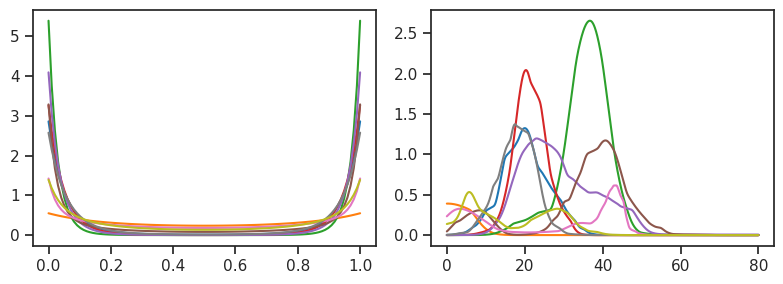

In [4]:
tau = dataloader.dataset.laplace.tau
omega = dataloader.dataset.laplace.omega
palette = ['C' + str(x) for x in range(250000)]
n_ex = 9
for C, G in dataloader:
    fig,axs = plt.subplots(1,2,figsize=(8,3))
    for j in range(n_ex):
        axs[0].plot(tau,G[j].cpu().detach().numpy().flatten(), color=palette[j])   
        axs[1].plot(omega,C[j].cpu().detach().numpy().flatten(), color=palette[j])
    plt.tight_layout()
    plt.show()

In [10]:
C.shape,stft(C.squeeze(1)).shape

(torch.Size([9, 1, 1024]), torch.Size([9, 46, 514]))

In [ ]:
# from einops.layers.torch import Rearrange
# class STFT(nn.Module):
#     def __init__(self, n_fft=90, hop_length=4, win_length=5):
#         super().__init__()
#         self.n_fft = n_fft
#         self.hop_length = hop_length
#         self.win_length = win_length
#         self.window = torch.hann_window(win_length)
#         self.rearrange = Rearrange(
#             "b c l z -> b c (l z)",
#         )
#     def forward(self, x):
#         # x: (batch, x_points)
#         x= torch.stft(
#             x,
#             n_fft=self.n_fft,
#             hop_length=self.hop_length,
#             win_length=self.win_length,
#             window=self.window,
#             return_complex=True
#         )
#         x = torch.view_as_real(x)
#         return self.rearrange(x)

# class ISTFT(nn.Module):
#     def __init__(self, n_fft=90, hop_length=4, win_length=5,length=1024):
#         super().__init__()
#         self.n_fft = n_fft
#         self.hop_length = hop_length
#         self.win_length = win_length
#         self.window = torch.hann_window(win_length)
#         self.length = length
#         self.rearrange = Rearrange(
#             "b c (l z) -> b c l z",
#             z=2,
#         )
#     def forward(self, x):
#         # x: (batch, x_points)
#         x = self.rearrange(x)
#         x = torch.view_as_complex(x)
#         return torch.istft(
#             x,
#             n_fft=self.n_fft,
#             hop_length=self.hop_length,
#             win_length=self.win_length,
#             window=self.window,
#             return_complex=False,
#             length=self.length
#         ) 


# stft = STFT()
# istft = ISTFT()
# stft_G=STFT(hop_length=1)
# istft_G = ISTFT(hop_length=1,length=99)


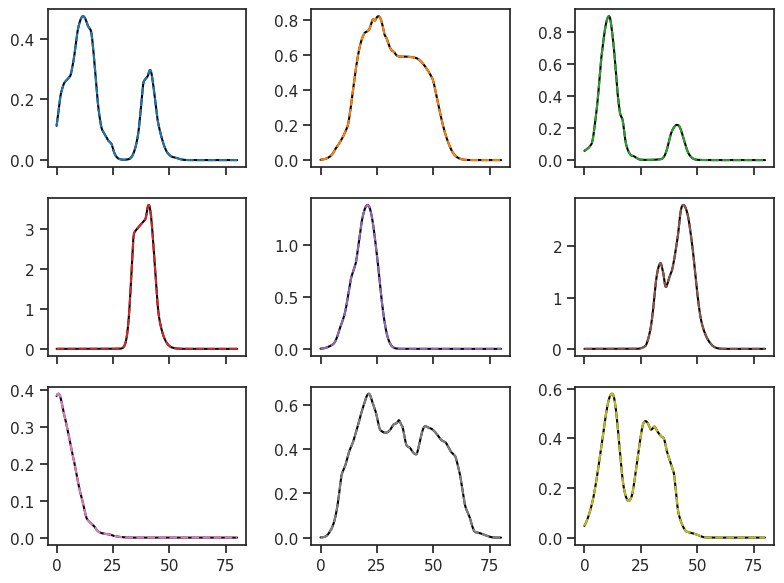

In [12]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
C_stft = istft(stft(C.squeeze(1)))
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C[j].view(1024).cpu().detach().numpy(), color='k')
    ax.plot(omega,C_stft[j].view(1024).cpu().detach().numpy(),'--', color=palette[j])
plt.tight_layout()
plt.show()

In [74]:
stft(C).shape

torch.Size([9, 46, 514])

In [89]:
Sxx = torch.view_as_complex(stft(C).reshape(9,46,-1,2)).abs()
Sxx.shape

torch.Size([9, 46, 257])

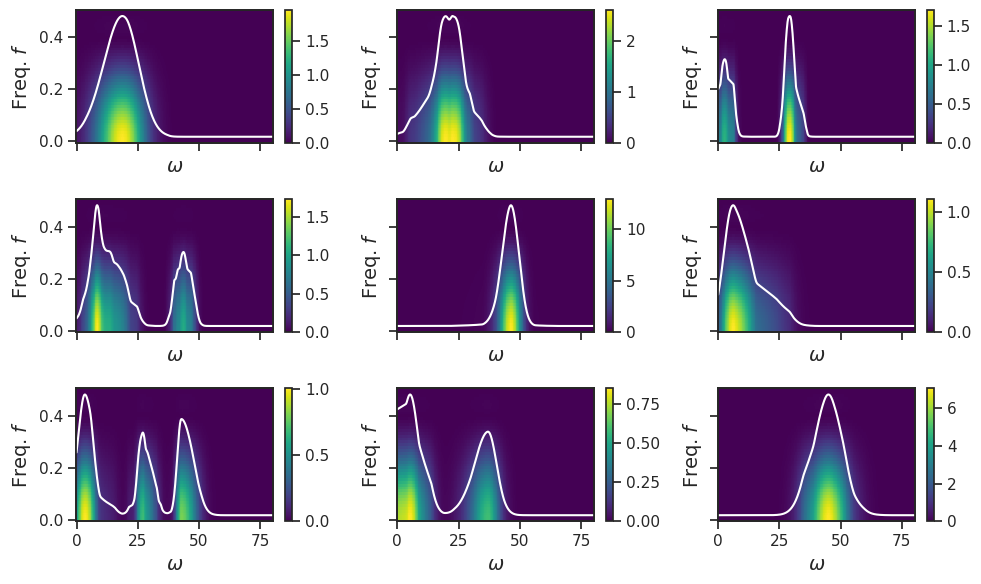

In [90]:
fig,axs = plt.subplots(3,3,figsize=(10,6),sharex=True,sharey=True)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.set(xlabel=f"$\omega$", ylabel=f"Freq. $f$")
    # im = ax.imshow(Sxx[j],origin='lower', aspect='auto', cmap='viridis')
    im=ax.pcolormesh(np.linspace(0,omega[-1],257),torch.fft.rfftfreq(90,1).numpy(),Sxx[j],cmap='viridis')
    fig.colorbar(im)
    ax2 = ax.twinx()
    ax2.plot(omega,C[j].view(1024).cpu().detach().numpy(), color='white')
    ax2.set_yticks(ticks=[],labels=None)
    # ax.plot(omega, torch.fft.rfftfreq(28,1).numpy(), 'r--', alpha=.5, label='$f_i(t)$')
    #,label="magnitude")
plt.tight_layout()
plt.show()

In [105]:
stft_G(G).shape

torch.Size([9, 46, 200])

In [106]:
Sxx = torch.view_as_complex(stft_G(G).reshape(9,46,-1,2)).abs()
Sxx.shape

torch.Size([9, 46, 100])

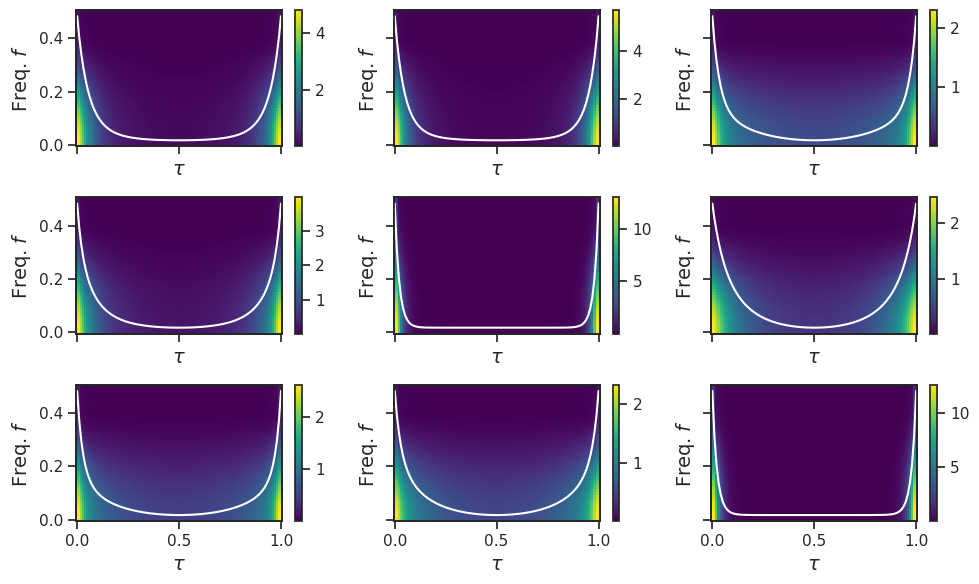

In [107]:
fig,axs = plt.subplots(3,3,figsize=(10,6),sharex=True,sharey=True)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.set(xlabel=r"$\tau$", ylabel=f"Freq. $f$")
    # im = ax.imshow(Sxx[j],origin='lower', aspect='auto', cmap='viridis')
    im=ax.pcolormesh(np.linspace(0,tau[-1],100),torch.fft.rfftfreq(90,1).numpy(),Sxx[j],cmap='viridis')
    fig.colorbar(im)
    ax2 = ax.twinx()
    ax2.plot(tau,G[j].view(99).cpu().detach().numpy(), color='white')
    ax2.set_yticks(ticks=[],labels=None)
    # ax.plot(omega, torch.fft.rfftfreq(28,1).numpy(), 'r--', alpha=.5, label='$f_i(t)$')
    #,label="magnitude")
plt.tight_layout()
plt.show()

In [70]:
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=10000,use_stft=True)
dataloader = DataLoader(dataset, batch_size=10000, shuffle=False,num_workers=0)

In [ ]:
for cc,gg in dataloader:
    pass

In [69]:
cc.mean((0,2)),cc.std((0,2))

(tensor([ 3.0253e-01, -3.1230e-01,  3.2039e-01, -3.2670e-01,  3.3114e-01,
         -3.3366e-01,  3.3423e-01, -3.3284e-01,  3.2952e-01, -3.2430e-01,
          3.1728e-01, -3.0853e-01,  2.9818e-01, -2.8637e-01,  2.7325e-01,
         -2.5900e-01,  2.4379e-01, -2.2783e-01,  2.1130e-01, -1.9441e-01,
          1.7736e-01, -1.6035e-01,  1.4355e-01, -1.2716e-01,  1.1133e-01,
         -9.6216e-02,  8.1949e-02, -6.8641e-02,  5.6385e-02, -4.5250e-02,
          3.5284e-02, -2.6514e-02,  1.8942e-02, -1.2551e-02,  7.3029e-03,
         -3.1410e-03, -7.9642e-06,  2.2318e-03, -3.6306e-03,  4.3138e-03,
         -4.3976e-03,  4.0021e-03, -3.2481e-03,  2.2544e-03, -1.1350e-03,
         -3.5923e-06]),
 tensor([1.0031e+00, 9.9795e-01, 9.8894e-01, 9.7618e-01, 9.5980e-01, 9.3996e-01,
         9.1686e-01, 8.9070e-01, 8.6174e-01, 8.3021e-01, 7.9641e-01, 7.6062e-01,
         7.2312e-01, 6.8423e-01, 6.4425e-01, 6.0349e-01, 5.6226e-01, 5.2085e-01,
         4.7957e-01, 4.3870e-01, 3.9852e-01, 3.5928e-01, 3.2122e-01

In [67]:
cc.mean((0,2)),cc.std((0,2))

(tensor([ 3.0763e-01, -3.1756e-01,  3.2578e-01, -3.3220e-01,  3.3671e-01,
         -3.3928e-01,  3.3986e-01, -3.3844e-01,  3.3506e-01, -3.2976e-01,
          3.2262e-01, -3.1372e-01,  3.0320e-01, -2.9119e-01,  2.7785e-01,
         -2.6336e-01,  2.4790e-01, -2.3166e-01,  2.1486e-01, -1.9769e-01,
          1.8035e-01, -1.6305e-01,  1.4597e-01, -1.2930e-01,  1.1321e-01,
         -9.7837e-02,  8.3329e-02, -6.9798e-02,  5.7335e-02, -4.6013e-02,
          3.5879e-02, -2.6961e-02,  1.9262e-02, -1.2763e-02,  7.4265e-03,
         -3.1944e-03, -7.5909e-06,  2.2690e-03, -3.6914e-03,  4.3862e-03,
         -4.4715e-03,  4.0694e-03, -3.3028e-03,  2.2924e-03, -1.1542e-03,
         -3.5185e-06]),
 tensor([1.0554e+00, 1.0502e+00, 1.0409e+00, 1.0277e+00, 1.0107e+00, 9.9000e-01,
         9.6587e-01, 9.3850e-01, 9.0816e-01, 8.7511e-01, 8.3963e-01, 8.0204e-01,
         7.6262e-01, 7.2172e-01, 6.7965e-01, 6.3673e-01, 5.9329e-01, 5.4966e-01,
         5.0614e-01, 4.6303e-01, 4.2064e-01, 3.7923e-01, 3.3907e-01

# Training

In [ ]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(num_bumps_range=(1,4)),
    denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256,n_channels=46,y_points=200,x_points=514),
    train_config=TrainConfig(compile=False, batch_size=50,n_epoch=200,use_wandb=True,save_model=True,model_name='STFT')
    )
model = main(model_cfg,use_stft=True)

In [ ]:
# model_cfg = ModelConfig(
#     data_config=SpectralDataConfig(num_bumps_range=(1,4)),
#     denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256,n_channels=46,y_points=200,x_points=514),
#     train_config=TrainConfig(compile=False, batch_size=50,n_epoch=200,use_wandb=True,save_model=True,model_name='STFT')
#     )
# from tld.denoiser import Denoiser
# model = Denoiser(**asdict(model_cfg.denoiser_config))
# model.load_state_dict(torch.load('STFT',map_location=torch.device('cuda'))["model_ema"])

<All keys matched successfully>

In [ ]:
hparams = asdict(model_cfg.data_config)
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 1, 99])


In [ ]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
istft(diffuser.generate(
        labels= stft_G(G_test.squeeze(1)).to('cuda'),
        num_specs=9,
        class_guidance=1,
        seed=1,
        n_iter=2,
        exponent=1,
        x_points=514,
        use_ddpm_plus=True
    )).shape

100%|██████████| 1/1 [00:00<00:00, 229.89it/s]


torch.Size([9, 1024])

In [24]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
istft.window=istft.window.to('cuda')
C_preds_list = [istft(diffuser.generate(
        labels= stft_G(G_test.squeeze(1)).to('cuda'),
        num_specs=9,
        class_guidance=1.5,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=514,
        use_ddpm_plus=True
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

100%|██████████| 39/39 [00:01<00:00, 38.73it/s]


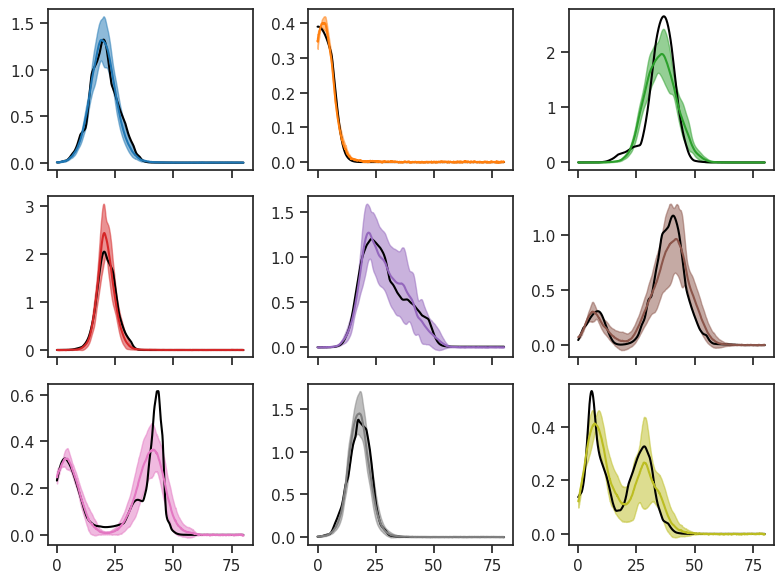

In [ ]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(omega_domain=(0,50),num_bumps_range=(1,7),bump_widths_fraction_range=(0.06,0.43)),
    denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256,n_channels=46,y_points=200,x_points=514),
    train_config=TrainConfig(compile=False, batch_size=100,n_epoch=500,use_wandb=True,save_model=True,model_name='STFT2')
    )
# model = main(model_cfg,use_stft=True)

In [4]:
from tld.denoiser import Denoiser
model = Denoiser(**asdict(model_cfg.denoiser_config))
model.load_state_dict(torch.load('STFT2',map_location=torch.device('cuda'))["model_ema"])

<All keys matched successfully>

In [7]:
model = model.to('cuda')

In [5]:
hparams = asdict(model_cfg.data_config)
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 1, 99])


In [12]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
istft.window=istft.window.to('cuda')
C_preds_list = [istft(diffuser.generate(
        labels= stft_G(G_test.squeeze(1)).to('cuda'),
        num_specs=9,
        class_guidance=1.,
        seed=i,
        n_iter=400,
        exponent=1,
        x_points=514,
        use_ddpm_plus=True
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

100%|██████████| 399/399 [00:11<00:00, 36.15it/s]


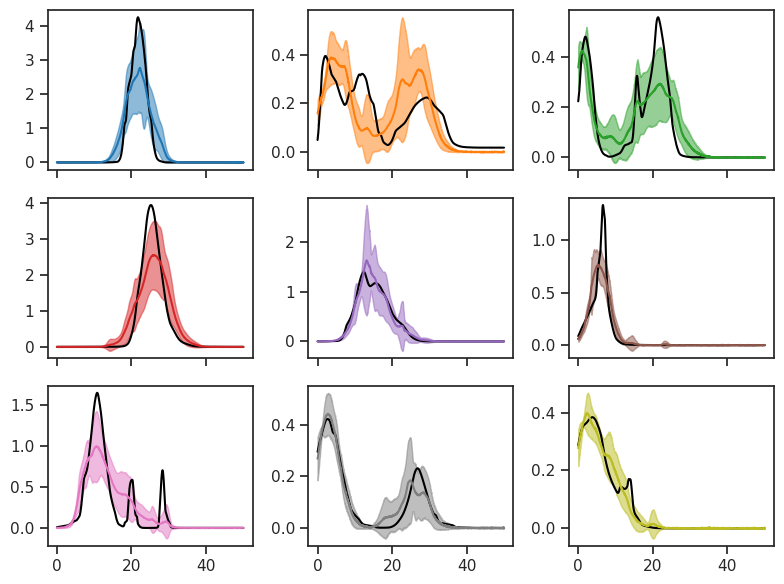

In [13]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

In [22]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
istft.window=istft.window.to('cuda')
C_preds_list = [istft(diffuser.generate(
        labels= stft_G(G_test.squeeze(1)).to('cuda'),
        num_specs=9,
        class_guidance=5.5,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=514,
        use_ddpm_plus=True
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

  0%|          | 0/39 [00:00<?, ?it/s]

100%|██████████| 39/39 [00:00<00:00, 39.37it/s]


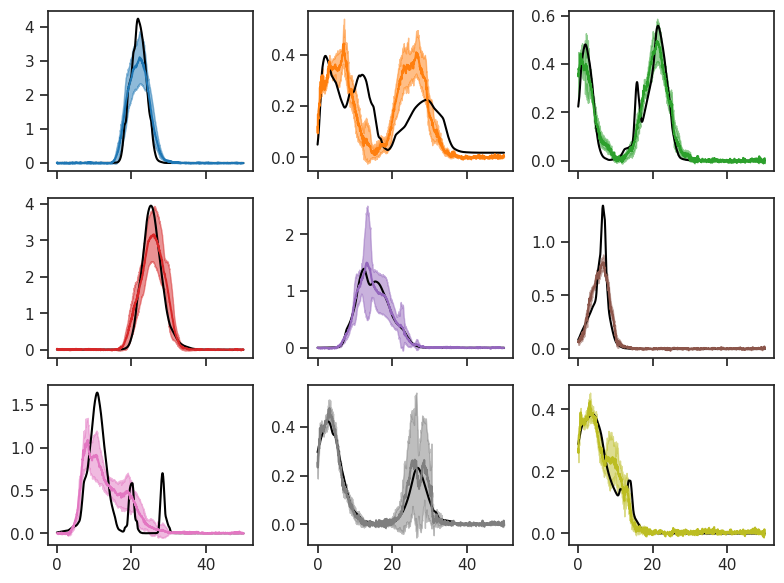

In [23]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

In [35]:
#params
kB = 3.1668114E-6  # in Hartree/K
c = 2.99792458E10  # speed of light in cm/s
s_in_t_au = 2.4188843265857E-17  # 1 time a.u. in s

T = 14.0  # in K

b = 1 / (kB * T)
print('beta is ' + str(b))


# rabani input:
Nbeads = 219
Natoms = 180
tau = test_loader.dataset.laplace.tau
# omega_dummy = np.linspace(omega_range[0], omega_range[1], Ng_w)

G_rabani = np.load('data/barak/G_Rabani_' + str(T) + 'K_' + str(Natoms) + 'p.npy')
tau_PIMD = G_rabani[0]
G_rabani = G_rabani[1]

# adds points to G
G_rabani_interp = np.interp(tau, tau_PIMD, G_rabani)
Norm_rabani = np.trapz(G_rabani_interp,tau)*np.pi
G_rabani_interp = G_rabani_interp / Norm_rabani

G_anal_tensor = torch.Tensor(G_rabani_interp)

# rabani output:
import pandas as pd
rabani_data = pd.read_csv("data/Rabani_D_w_14K.csv", sep=",", header=None)
rabani_data_w, rabani_data_D = rabani_data[0].values,rabani_data[1].values
rabani_data_w *= ( 2 * np.pi * c * s_in_t_au * b ) # now omega unitless



# # PIMD with I-pi input:
Nbeads = 50
df=pd.read_csv('/home/sagi/Desktop/parahydrogen/pH2_for_Amit/G_14K_50beads_180p_ipi_sym.csv')
_, G_rabani = df['tau'].values,df['G'].values

# # interpolate - adding points to G
tau_PIMD = np.linspace(0,1,Nbeads+1)
G_rabani_interp_2 = np.interp(tau, tau_PIMD, G_rabani)
Correct_norm = np.trapz(G_rabani_interp_2,tau)*np.pi
G_rabani_interp_2 = G_rabani_interp_2 / Correct_norm 

G_anal_tensor_2 = torch.Tensor(G_rabani_interp_2)

beta is 22555.360078775586


In [73]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
istft.window=istft.window.to('cuda')
C_preds_list_rabani = [istft(diffuser.generate(
        labels= stft_G(G_anal_tensor.view(1,-1)).to('cuda').unsqueeze(0),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=2,
        exponent=1,
        x_points=514,
        use_ddpm_plus=True
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani = C_preds_array.mean(0)
C_preds_std_rabani = C_preds_array.std(0)

100%|██████████| 1/1 [00:00<00:00, 277.84it/s]


In [74]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
istft.window=istft.window.to('cuda')
C_preds_list_rabani = [istft(diffuser.generate(
        labels= stft_G(G_anal_tensor_2.view(1,-1)).to('cuda').unsqueeze(0),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=2,
        exponent=1,
        x_points=514,
        use_ddpm_plus=True
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani_2 = C_preds_array.mean(0)
C_preds_std_rabani_2 = C_preds_array.std(0)

100%|██████████| 1/1 [00:00<00:00, 257.16it/s]


In [47]:
mass=2.01588 # gram/mol
hbar = 1.054571817 * 1E-34 # J * sec = kg * m^2 /sec
hbar *= 1E+20 # kg * angstrom^2 /sec
hbar *= 1E-12 # kg * angstrom^2 /ps
mass /= (1000 * 6.02214076 * 1E+23) # kg
renorm_factor = hbar*3*np.pi/mass

0.3770891485573278
0.36998987929281224
0.2881096360834827


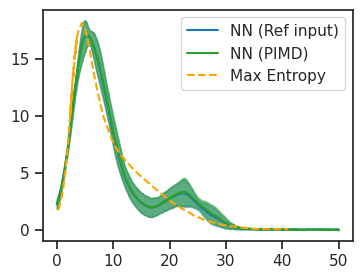

In [75]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,renorm_factor*C_preds_mean_rabani[0],label='NN (Ref input)',color='tab:blue')
ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani[0]-C_preds_std_rabani[0]),renorm_factor*(C_preds_mean_rabani[0]+C_preds_std_rabani[0]),color='tab:blue',alpha=0.5)
print(renorm_factor*C_preds_mean_rabani[0][0]/6)
ax.plot(omega,renorm_factor*C_preds_mean_rabani_2[0],color='tab:green',label='NN (PIMD)')
ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani_2[0]-C_preds_std_rabani_2[0]),renorm_factor*(C_preds_mean_rabani_2[0]+C_preds_std_rabani_2[0]),color='tab:green',alpha=0.5)
print(renorm_factor*C_preds_mean_rabani_2[0][0]/6)
ax.plot(rabani_data_w,rabani_data_D*6,'--',color='orange',label='Max Entropy')
print(rabani_data_D[0])
ax.legend()

In [116]:
velFT = np.loadtxt('/home/sagi/Desktop/water/1bead/nve1/nve_facf.data', usecols=(0,1))
velFT = velFT[velFT[:,0] * 219474<=8000]
water_data_w, water_nve_D = velFT[:,0]* 219474 * ( 2 * np.pi * c * s_in_t_au /kB/300 ), velFT[:,1]
norm_water_nve_D=np.trapz(y=water_nve_D,x=water_data_w)
water_nve_D/=norm_water_nve_D
water_nve_D *= (water_data_w + 1E-30) / (1-np.exp(-water_data_w) + 1E-30)


Nbeads = 32
df=pd.read_csv('/home/sagi/Desktop/water/G_300K_32beads_sym.csv')
_, G_water = df['tau'].values,df['G'].values

G_water_interp = np.interp(tau, np.linspace(0,1,Nbeads+1), G_water)
Norm_water = np.trapz(G_water_interp,tau)*np.pi
G_water_interp = G_water_interp / Norm_water
G_water_tensor = torch.Tensor(G_water_interp)

K = ( np.exp(- water_data_w * tau[:,None]) + np.exp(water_data_w * (tau - 1)[:,None]) )/2/np.pi
G_water_interp2 = np.trapz(y=K*water_nve_D,x=water_data_w)
print(np.trapz(y=G_water_interp2,x=tau)*np.pi)
G_water_tensor2 = torch.Tensor(G_water_interp2)

1.000926779558307


In [118]:
# plt.plot(G_water_interp)
# plt.plot(G_water_interp2)

In [124]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds_list_water = [istft(diffuser.generate(
        labels= stft_G(G_water_tensor.view(1,-1)).to('cuda').unsqueeze(0),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=514,
        use_ddpm_plus=True
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_water)
C_preds_mean_water = C_preds_array.mean(0)
C_preds_std_water = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 252.22it/s]


In [125]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds_list_water = [istft(diffuser.generate(
        labels= stft_G(G_water_tensor2.view(1,-1)).to('cuda').unsqueeze(0),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=514,
        use_ddpm_plus=True
    )).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_water)
C_preds_mean_water2 = C_preds_array.mean(0)
C_preds_std_water2 = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 255.41it/s]


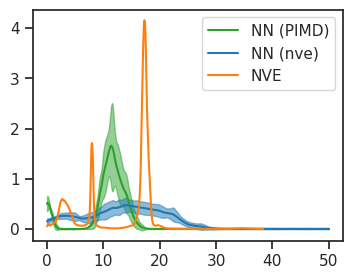

In [ ]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,C_preds_mean_water[0],label='NN (PIMD)',color='tab:green')
ax.fill_between(omega,(C_preds_mean_water[0]-C_preds_std_water[0]),(C_preds_mean_water[0]+C_preds_std_water[0]),color='tab:green',alpha=0.5)
ax.plot(omega,C_preds_mean_water2[0],label='NN (nve)',color='tab:blue')
ax.fill_between(omega,(C_preds_mean_water2[0]-C_preds_std_water2[0]),(C_preds_mean_water2[0]+C_preds_std_water2[0]),color='tab:blue',alpha=0.5)

ax.plot(water_data_w,water_nve_D,color='tab:orange',label='NVE')
ax.legend()

In [18]:
Sxx = torch.view_as_complex(stft(C_test.squeeze(1)).reshape(9,46,-1,2)).abs()
Sxx.shape

torch.Size([9, 46, 257])

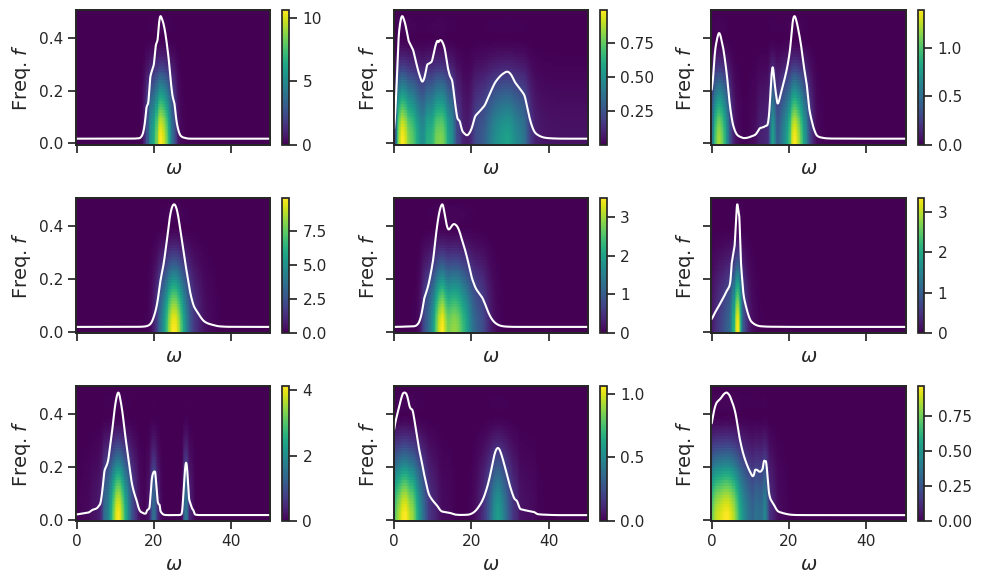

In [19]:
fig,axs = plt.subplots(3,3,figsize=(10,6),sharex=True,sharey=True)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.set(xlabel=f"$\omega$", ylabel=f"Freq. $f$")
    # im = ax.imshow(Sxx[j],origin='lower', aspect='auto', cmap='viridis')
    im=ax.pcolormesh(np.linspace(0,omega[-1],257),torch.fft.rfftfreq(90,1).numpy(),Sxx[j],cmap='viridis')
    fig.colorbar(im)
    ax2 = ax.twinx()
    ax2.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='white')
    ax2.set_yticks(ticks=[],labels=None)
    # ax.plot(omega, torch.fft.rfftfreq(28,1).numpy(), 'r--', alpha=.5, label='$f_i(t)$')
    #,label="magnitude")
plt.tight_layout()
plt.show()

tensor(-15.4402)